**Week1: Project Initialization and Dataset Acquisition**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

# Path to your Drive (My Drive is the root folder)
folder_path = "/content/drive/MyDrive/VisionExtract"

# Create folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print("✅ Folder created:", folder_path)
else:
    print("⚡ Folder already exists:", folder_path)


✅ Folder created: /content/drive/MyDrive/VisionExtract


In [17]:
import os

train_folder = "/content/drive/MyDrive/VisionExtract/train2017_subset"
val_folder = "/content/drive/MyDrive/VisionExtract/val2017"

train_images = [f for f in os.listdir(train_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
val_images = [f for f in os.listdir(val_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

print("Training images:", len(train_images))
print("Validation images:", len(val_images))


Training images: 1759
Validation images: 5000


In [20]:
import json

annotation_file = "/content/drive/MyDrive/VisionExtract/annotations/instances_val2017.json"  # example path

with open(annotation_file) as f:
    data = json.load(f)

# List all categories
categories = data['categories']
for cat in categories:
    print(f"ID: {cat['id']}, Name: {cat['name']}")


ID: 1, Name: person
ID: 2, Name: bicycle
ID: 3, Name: car
ID: 4, Name: motorcycle
ID: 5, Name: airplane
ID: 6, Name: bus
ID: 7, Name: train
ID: 8, Name: truck
ID: 9, Name: boat
ID: 10, Name: traffic light
ID: 11, Name: fire hydrant
ID: 13, Name: stop sign
ID: 14, Name: parking meter
ID: 15, Name: bench
ID: 16, Name: bird
ID: 17, Name: cat
ID: 18, Name: dog
ID: 19, Name: horse
ID: 20, Name: sheep
ID: 21, Name: cow
ID: 22, Name: elephant
ID: 23, Name: bear
ID: 24, Name: zebra
ID: 25, Name: giraffe
ID: 27, Name: backpack
ID: 28, Name: umbrella
ID: 31, Name: handbag
ID: 32, Name: tie
ID: 33, Name: suitcase
ID: 34, Name: frisbee
ID: 35, Name: skis
ID: 36, Name: snowboard
ID: 37, Name: sports ball
ID: 38, Name: kite
ID: 39, Name: baseball bat
ID: 40, Name: baseball glove
ID: 41, Name: skateboard
ID: 42, Name: surfboard
ID: 43, Name: tennis racket
ID: 44, Name: bottle
ID: 46, Name: wine glass
ID: 47, Name: cup
ID: 48, Name: fork
ID: 49, Name: knife
ID: 50, Name: spoon
ID: 51, Name: bowl
ID: 5

**Segmented image**
**:**

Found existing installation: pycocotools 2.0.10
Uninstalling pycocotools-2.0.10:
  Successfully uninstalled pycocotools-2.0.10
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycocotools: filename=pycocotools-2.0.10-cp312-abi3-linux_x86_64.whl size=322401 sha256=54932850096bddcd951ab286ce4375d3efb3648bdd9cf7d9c5e0693318c54250
  Stored in directory: /root/.cache/pip/wheels/21/45/b6/f489741f07985a1b09fd4c8339cf7e20f6a052e7290c690b4b
Successfully built pycocotools
loading annotations into memory...
Done (t=0.37s)
creating index...
index created!


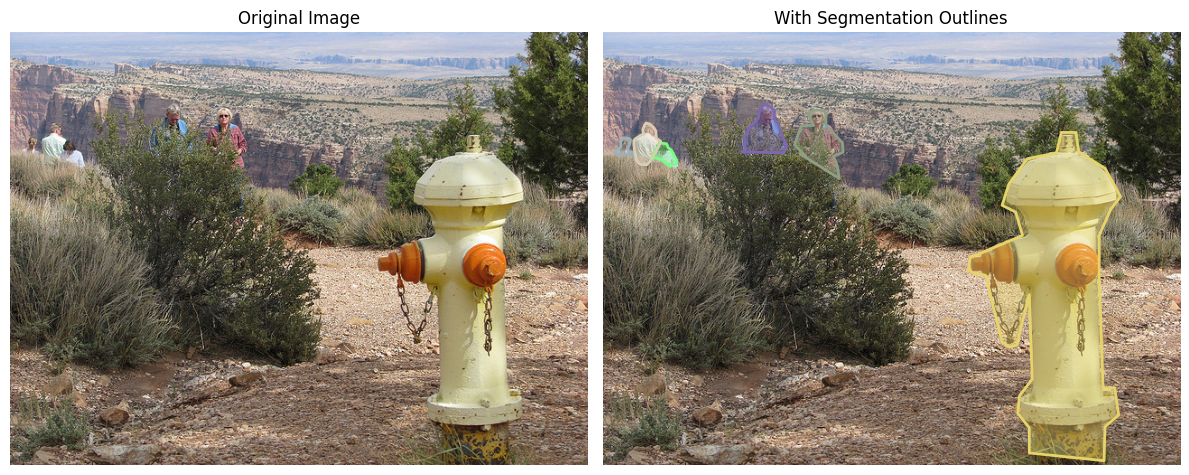

In [21]:
# =========================
# Step 0: Install pycocotools correctly
# =========================
!pip uninstall -y pycocotools
!pip install pycocotools --no-binary pycocotools

# =========================
# Step 1: Imports
# =========================
import os
import random
import matplotlib.pyplot as plt
import cv2
from pycocotools.coco import COCO

# ======================
# Step 2: Paths
# ======================
ANN_FILE = "/content/drive/MyDrive/VisionExtract/annotations/instances_val2017.json"
IMG_DIR = "/content/drive/MyDrive/VisionExtract/val2017"

# Load COCO dataset
coco = COCO(ANN_FILE)

# ======================
# Step 3: Pick a random image
# ======================
img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs(img_id)[0]

# Load image
img_path = os.path.join(IMG_DIR, img_info['file_name'])
image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

# Load annotations for this image
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

# ======================
# Step 4: Plot Left (Original) + Right (With Outlines)
# ======================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left → Original Image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Right → Image with COCO segmentation outlines
plt.sca(axes[1])
plt.imshow(image)
coco.showAnns(anns)  # overlays segmentation outlines
plt.title("With Segmentation Outlines")
plt.axis("off")

plt.tight_layout()
plt.show()


**Display Random Original Images with segmented Images:**

loading annotations into memory...
Done (t=0.40s)
creating index...
index created!


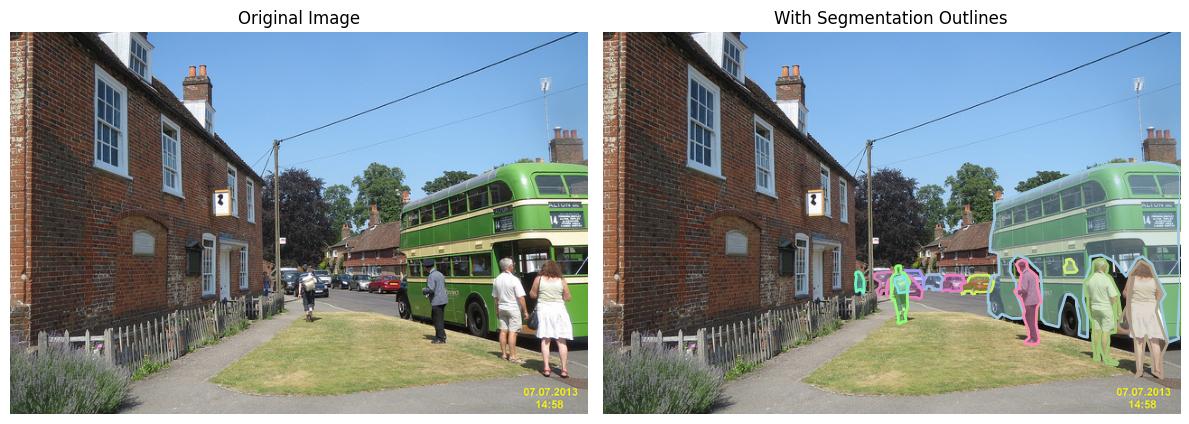

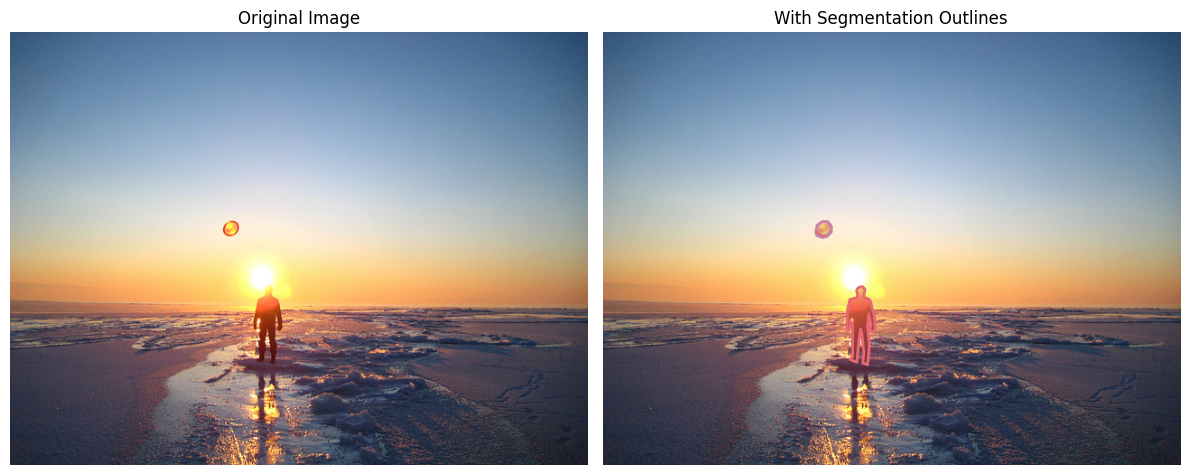

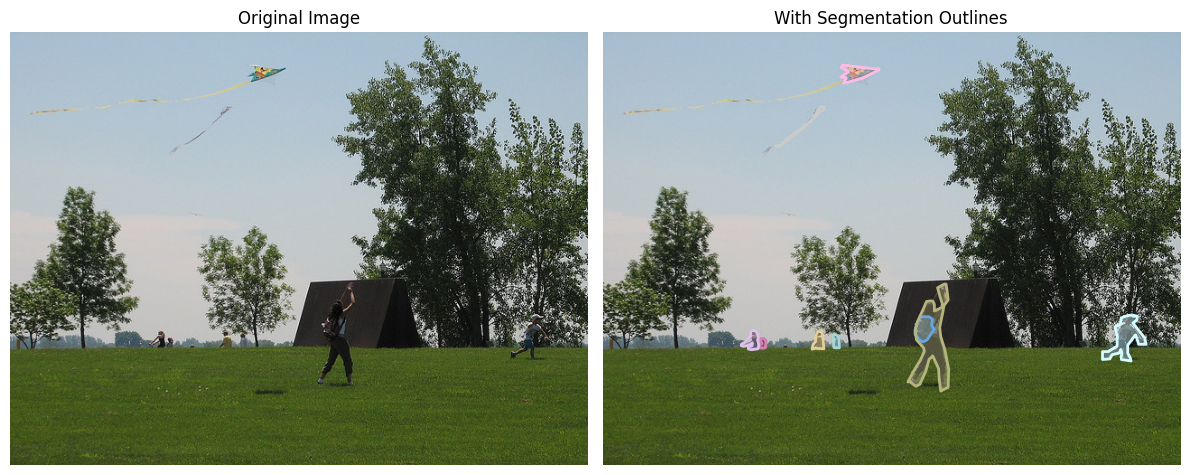

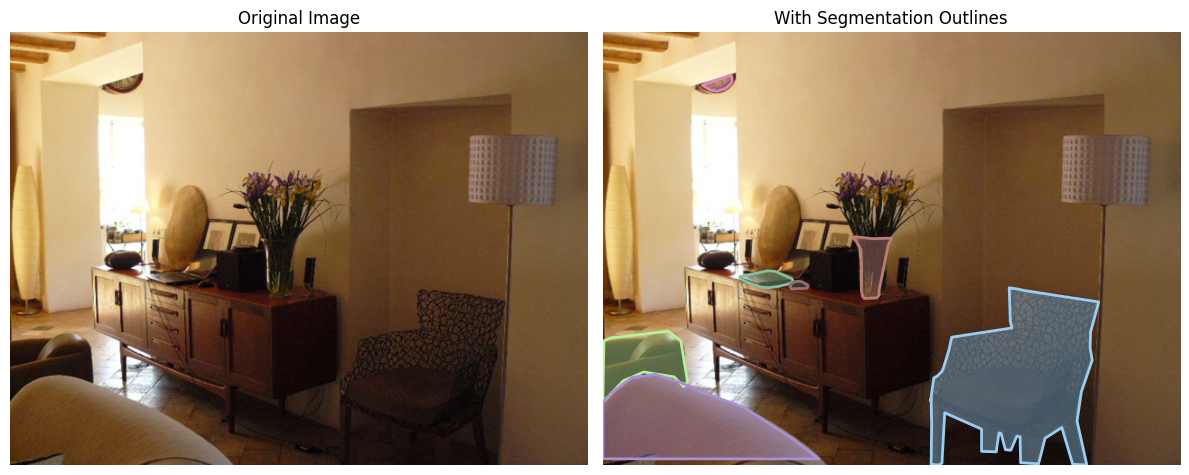

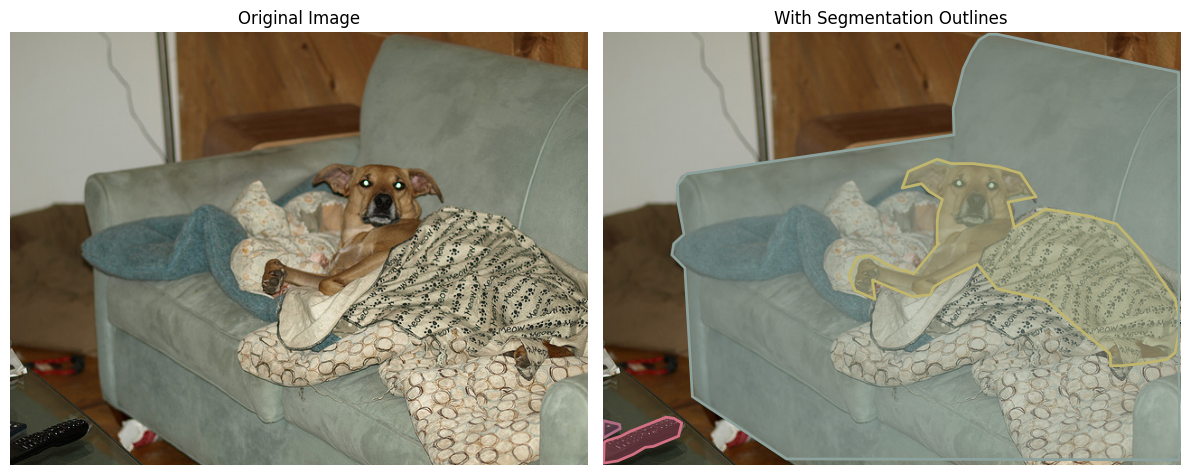

In [24]:
# =========================
# Step 1: Imports
# =========================
import os
import random
import matplotlib.pyplot as plt
import cv2
from pycocotools.coco import COCO

# ======================
# Step 2: Paths
# ======================
ANN_FILE = "/content/drive/MyDrive/VisionExtract/annotations/instances_val2017.json"
IMG_DIR = "/content/drive/MyDrive/VisionExtract/val2017"

# Load COCO dataset
coco = COCO(ANN_FILE)

# ======================
# Step 3: Function to visualize one image with annotations
# ======================
def visualize_image_with_annotations(img_id):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMG_DIR, img_info['file_name'])
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Left → Original Image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Right → Image with COCO segmentation outlines
    plt.sca(axes[1])
    plt.imshow(image)
    coco.showAnns(anns)
    plt.title("With Segmentation Outlines")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ======================
# Step 4: Pick 5 random images and visualize
# ======================
random_img_ids = random.sample(coco.getImgIds(), 5)

for img_id in random_img_ids:
    visualize_image_with_annotations(img_id)


**Display Random Original Images with masked Images:**

loading annotations into memory...
Done (t=0.56s)
creating index...
index created!


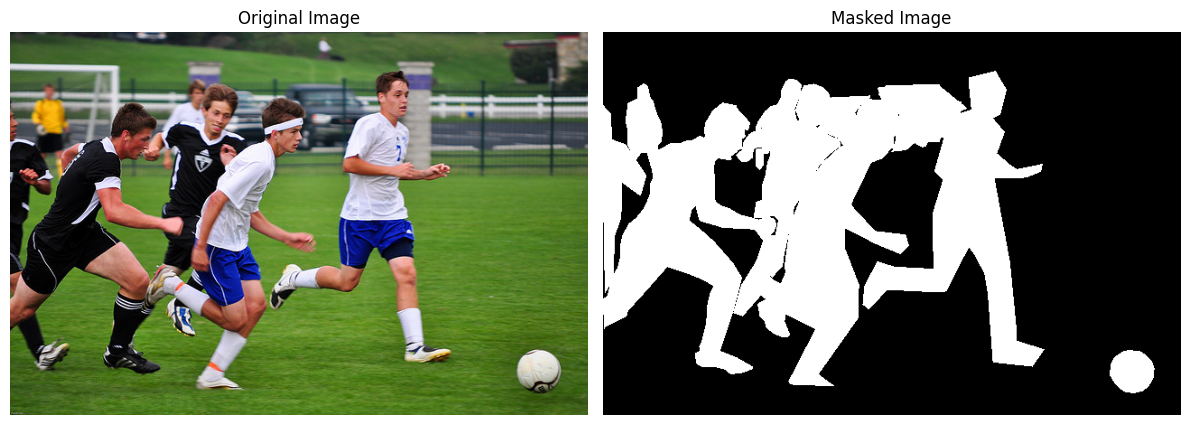

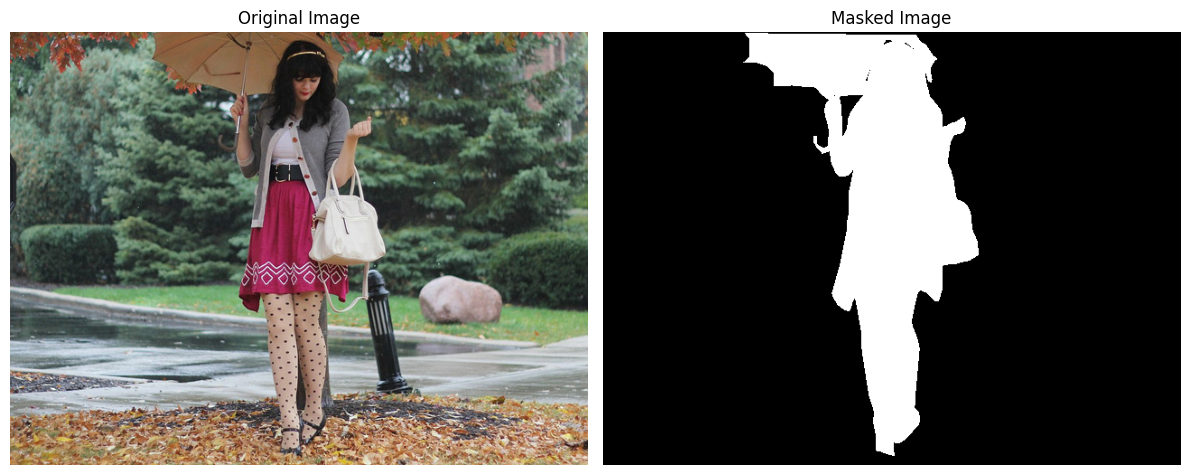

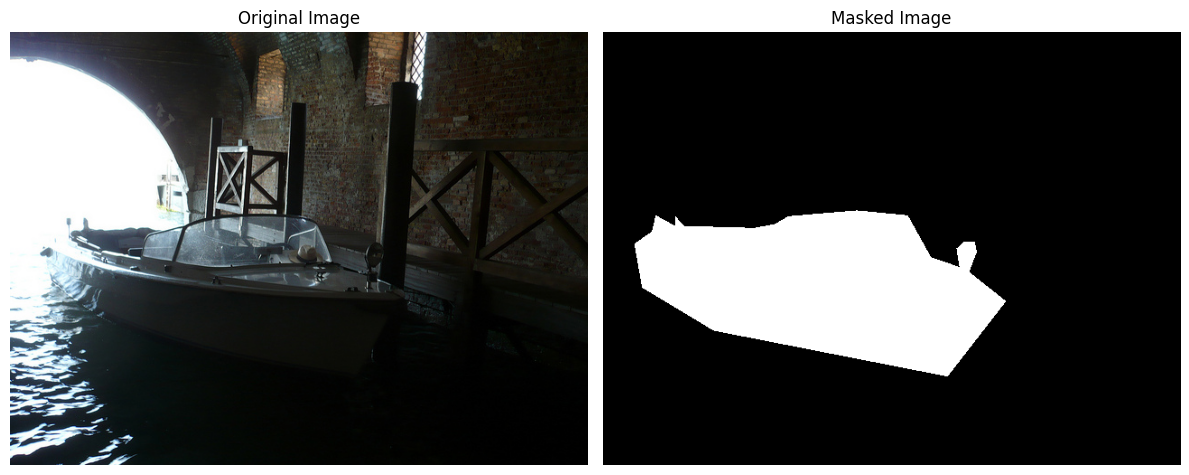

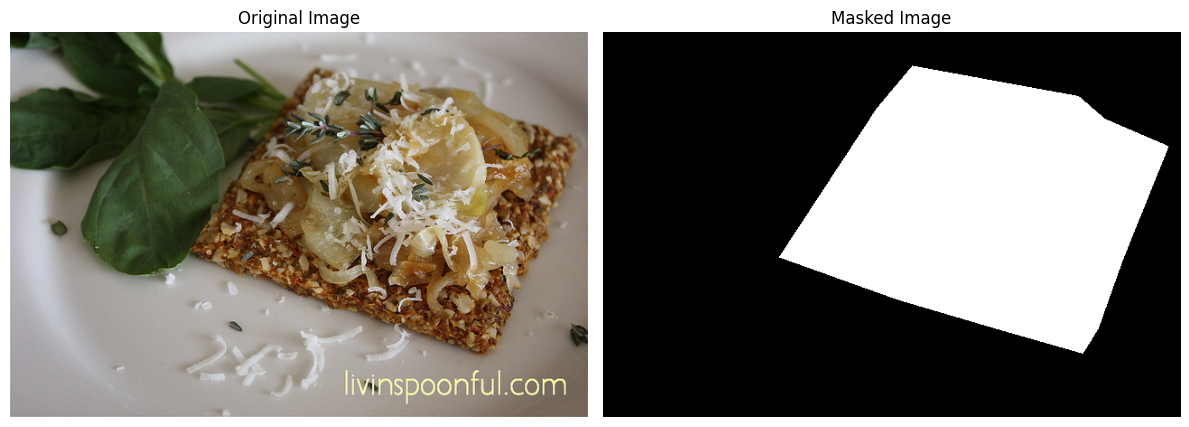

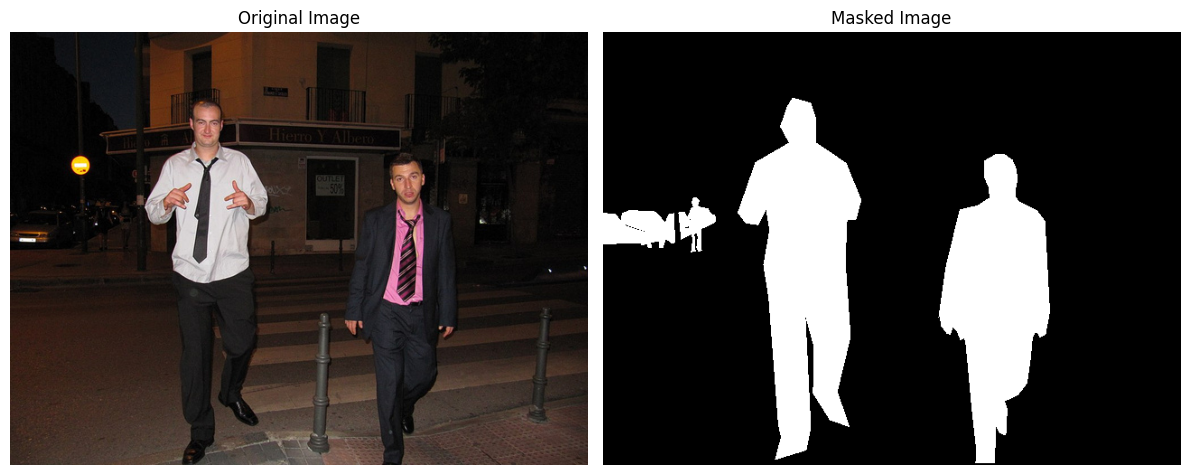

In [26]:
# =========================
# Step 1: Imports
# =========================
import os
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils  # for decoding COCO RLE masks

# ======================
# Step 2: Paths
# ======================
ANN_FILE = "/content/drive/MyDrive/VisionExtract/annotations/instances_val2017.json"
IMG_DIR = "/content/drive/MyDrive/VisionExtract/val2017"

# Load COCO dataset
coco = COCO(ANN_FILE)

# ======================
# Step 3: Function to visualize image with combined mask
# ======================
def visualize_image_and_mask(img_id):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMG_DIR, img_info['file_name'])

    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        return

    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    # Create empty mask
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

    # Load annotations for this image
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        if 'segmentation' in ann:
            rle = mask_utils.frPyObjects(ann['segmentation'], img_info['height'], img_info['width'])
            decoded_mask = mask_utils.decode(rle)

            # If decoded_mask is 3D, sum along last dimension
            if decoded_mask.ndim == 3:
                decoded_mask = np.sum(decoded_mask, axis=2)

            mask += decoded_mask

    # Clip mask to 0-1 range
    mask = np.clip(mask, 0, 1)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Masked Image")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# ======================
# Step 4: Pick 5 random images and visualize
# ======================
random_img_ids = random.sample(coco.getImgIds(), 5)

for img_id in random_img_ids:
    visualize_image_and_mask(img_id)
